# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/regression.csv')
print(df.columns.tolist())
df.head()

['uid', 'num_commits', 'pageviews', 'AVG(diff)']


,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,-64.400000
1,user_10,20,89.0,-74.800000
2,user_14,61,143.0,-159.000000
3,user_17,51,47.0,-61.600000
4,user_18,5,3.0,-5.666667


In [3]:
# Remove pageviews, keep only num_commits and AVG(diff)
df = df.drop(columns=['pageviews'], errors='ignore')

# Get numeric columns only (drop uid)
X = df.select_dtypes(include=[np.number]).values
print('Shape:', X.shape)
print('Columns used:', df.select_dtypes(include=[np.number]).columns.tolist())

Shape: (29, 2)
Columns used: ['num_commits', 'AVG(diff)']


## 2. KMeans

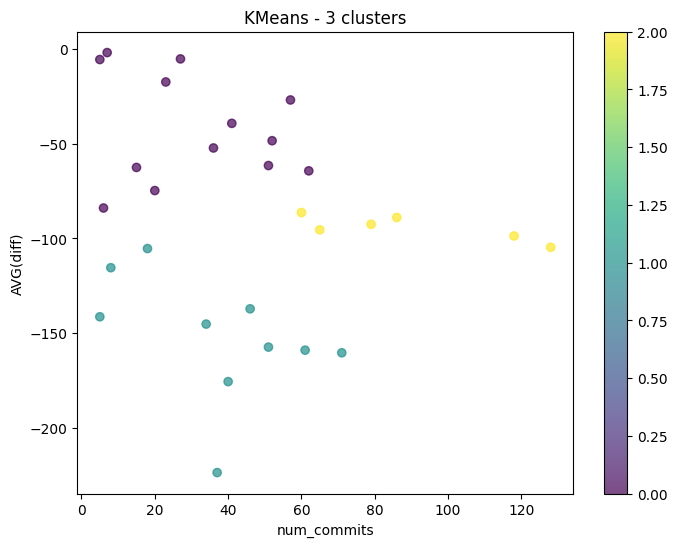

Silhouette score (n=3): 0.4454


In [4]:
# Baseline: 3 clusters
kmeans = KMeans(n_clusters=3, random_state=21)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('KMeans - 3 clusters')
plt.colorbar()
plt.show()

score = silhouette_score(X, labels)
print(f'Silhouette score (n=3): {score:.4f}')

In [5]:
# Try different n_clusters
for n in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=n, random_state=21)
    lbl = km.fit_predict(X)
    score = silhouette_score(X, lbl)
    print(f'n_clusters={n}: silhouette={score:.4f}')

n_clusters=2: silhouette=0.4195
n_clusters=3: silhouette=0.4454
n_clusters=4: silhouette=0.4150
n_clusters=5: silhouette=0.3521
n_clusters=6: silhouette=0.3954


## 3. DBSCAN

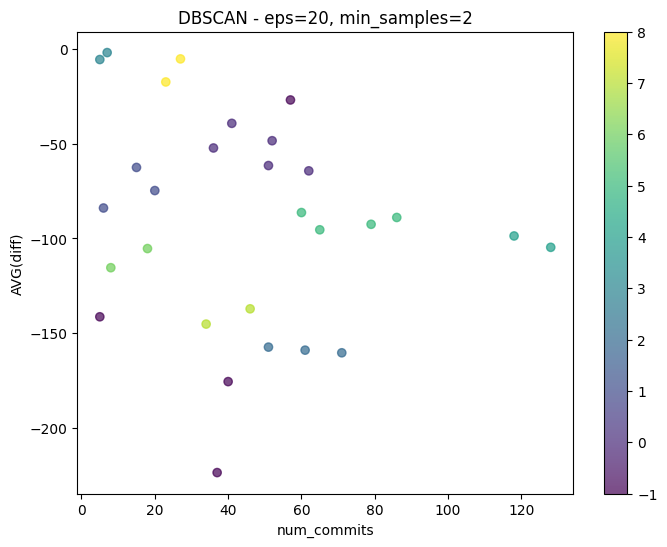

Number of clusters: 9
Silhouette score: 0.5442


In [6]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('DBSCAN - eps=20, min_samples=2')
plt.colorbar()
plt.show()

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters: {n_clusters}')
if n_clusters > 1:
    mask = labels != -1
    score = silhouette_score(X[mask], labels[mask])
    print(f'Silhouette score: {score:.4f}')

In [7]:
# Try different eps and min_samples
for eps in [10, 20, 30, 50]:
    for min_s in [2, 3]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db.fit_predict(X)
        n = len(set(lbl)) - (1 if -1 in lbl else 0)
        if n > 1:
            mask = lbl != -1
            score = silhouette_score(X[mask], lbl[mask])
            print(f'eps={eps}, min_samples={min_s}: clusters={n}, silhouette={score:.4f}')
        else:
            print(f'eps={eps}, min_samples={min_s}: clusters={n} (not enough)')

eps=10, min_samples=2: clusters=2, silhouette=0.9480
eps=10, min_samples=3: clusters=0 (not enough)
eps=20, min_samples=2: clusters=9, silhouette=0.5442
eps=20, min_samples=3: clusters=4, silhouette=0.6011
eps=30, min_samples=2: clusters=2, silhouette=0.2648
eps=30, min_samples=3: clusters=1 (not enough)
eps=50, min_samples=2: clusters=1 (not enough)
eps=50, min_samples=3: clusters=1 (not enough)


## 4. Hierarchical (AgglomerativeClustering)

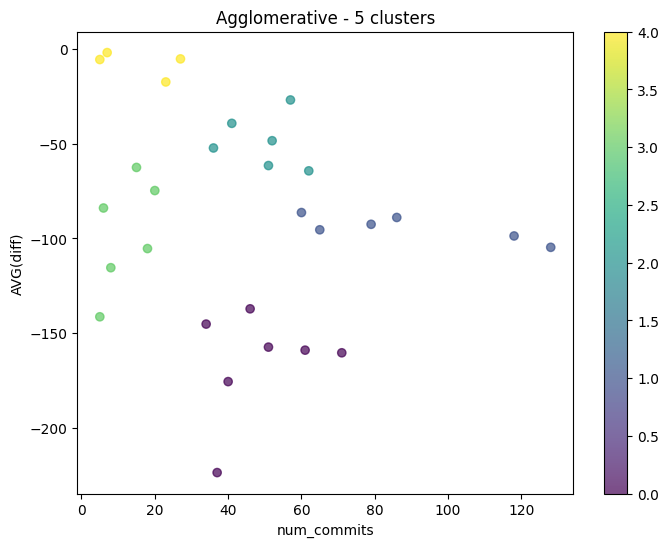

Silhouette score (n=5): 0.4638


In [8]:
agg = AgglomerativeClustering(n_clusters=5)
labels = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('Agglomerative - 5 clusters')
plt.colorbar()
plt.show()

score = silhouette_score(X, labels)
print(f'Silhouette score (n=5): {score:.4f}')

In [9]:
# Try different n_clusters
for n in [2, 3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=n)
    lbl = agg.fit_predict(X)
    score = silhouette_score(X, lbl)
    print(f'n_clusters={n}: silhouette={score:.4f}')

n_clusters=2: silhouette=0.3590
n_clusters=3: silhouette=0.3390
n_clusters=4: silhouette=0.4448
n_clusters=5: silhouette=0.4638
n_clusters=6: silhouette=0.4527


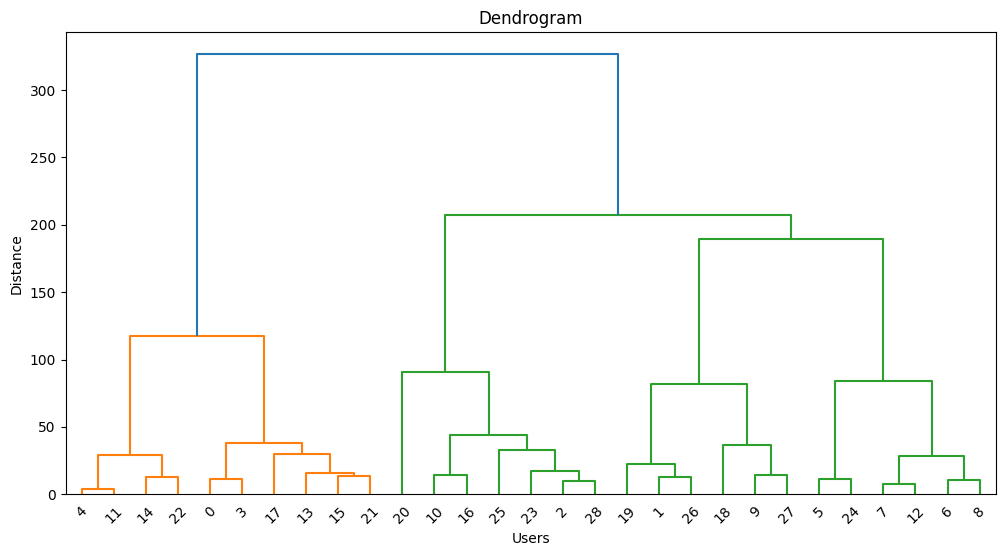

In [10]:
# Dendrogram
linked = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Users')
plt.ylabel('Distance')
plt.show()

## 5. Function

Best n_clusters=3, silhouette=0.4454


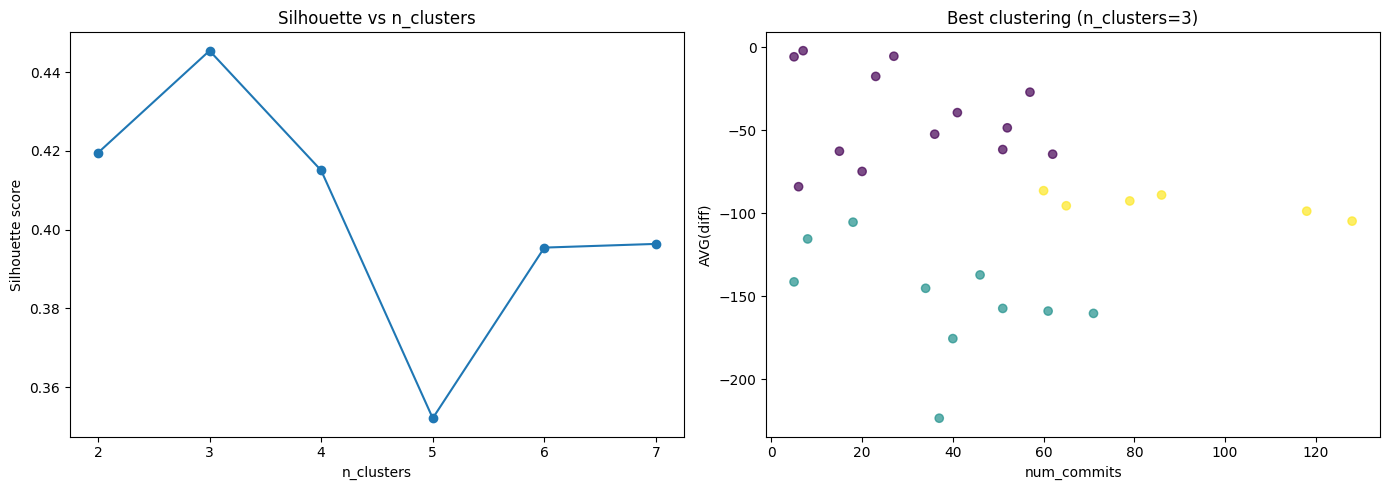

In [11]:
def optimize_clustering(model_class, model_params, param_name, param_range, X):
    scores = []
    best_score = -1
    best_val = None
    best_labels = None

    for val in param_range:
        params = {**model_params, param_name: val}
        model = model_class(**params)
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            mask = labels != -1
            score = silhouette_score(X[mask], labels[mask])
        else:
            score = -1
        scores.append(score)
        if score > best_score:
            best_score = score
            best_val = val
            best_labels = labels

    print(f'Best {param_name}={best_val}, silhouette={best_score:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(param_range, scores, marker='o')
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('Silhouette score')
    axes[0].set_title(f'Silhouette vs {param_name}')

    axes[1].scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', alpha=0.7)
    axes[1].set_xlabel('num_commits')
    axes[1].set_ylabel('AVG(diff)')
    axes[1].set_title(f'Best clustering ({param_name}={best_val})')

    plt.tight_layout()
    plt.show()

# Test the function with KMeans
optimize_clustering(KMeans, {'random_state': 21}, 'n_clusters', range(2, 8), X)

Best n_clusters=7, silhouette=0.4866


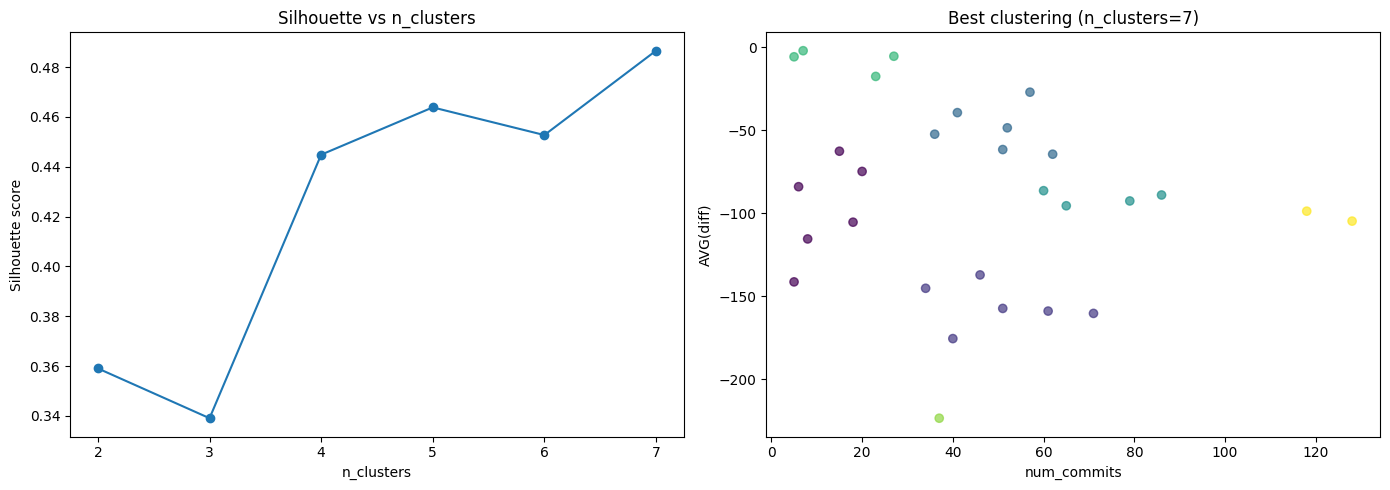

In [12]:
# Test with AgglomerativeClustering
optimize_clustering(AgglomerativeClustering, {}, 'n_clusters', range(2, 8), X)